# GeoVision-CLIP Cali — Situación 2 · Notebook 6
## Auditoría estadística de tiles

Este notebook revisa la calidad estadística de `tiles_train.npz` y `tiles_meta.parquet` antes de seguir entrenando modelos. No usa `torch` ni GPU. Genera tablas y figuras en `/kaggle/working/auditoria_tiles/`.

In [4]:
from __future__ import annotations

from pathlib import Path
import json

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 200)
pd.set_option("display.width", 220)

KAGGLE_INPUT = Path("/kaggle/input")
KAGGLE_TILES_PATH = KAGGLE_INPUT / "datasets/edwardsx/geovision-tiles-sit2"
if not KAGGLE_TILES_PATH.exists():
    KAGGLE_TILES_PATH = KAGGLE_INPUT / "geovision-tiles-sit2"

LOCAL_TILES_PATH = Path("/home/yeigen/Documents/proyecto-3/data/tiles_sit2")
if (KAGGLE_TILES_PATH / "tiles_train.npz").exists():
    TILES_PATH = KAGGLE_TILES_PATH
elif (LOCAL_TILES_PATH / "tiles_train.npz").exists():
    TILES_PATH = LOCAL_TILES_PATH
else:
    raise FileNotFoundError(
        "No encontré tiles_train.npz. En Kaggle debe estar en el dataset edwardsx/geovision-tiles-sit2; "
        "en local debe estar en data/."
    )

if Path("/kaggle/working").exists():
    OUTPUT = Path("/kaggle/working")
else:
    OUTPUT = Path("auditoria_tiles_local_output")

AUDIT_DIR = OUTPUT / "auditoria_tiles"
FIG_DIR = AUDIT_DIR / "figuras"
TABLE_DIR = AUDIT_DIR / "tablas"
FIG_DIR.mkdir(parents=True, exist_ok=True)
TABLE_DIR.mkdir(parents=True, exist_ok=True)

CLASES = [
    "contaminacion_alta_NO2",
    "contaminacion_alta_SO2",
    "ozono_anomalo",
    "vegetacion_densa",
    "suelo_urbano",
]

print(f"Tiles path: {TILES_PATH}")
print(f"Output: {AUDIT_DIR}")

Tiles path: /home/yeigen/Documents/proyecto-3/data/tiles_sit2
Output: auditoria_tiles_local_output/auditoria_tiles


In [5]:
npz = np.load(TILES_PATH / "tiles_train.npz", allow_pickle=False)
tiles = npz["data"]
bandas = [str(b) for b in npz["bands"]]
meta = pd.read_parquet(TILES_PATH / "tiles_meta.parquet")

print(f"Tiles shape: {tiles.shape}")
print(f"Bandas ({len(bandas)}): {bandas}")
print(f"Meta shape: {meta.shape}")
print(f"Meta columnas ({len(meta.columns)}): {list(meta.columns)}")
print()
print(meta["clase"].value_counts().reindex(CLASES).to_string())
print()
print(f"Fechas únicas: {meta['time_s2'].nunique()}")
print(f"Lat: {meta['lat'].min():.5f} a {meta['lat'].max():.5f}")
print(f"Lon: {meta['lon'].min():.5f} a {meta['lon'].max():.5f}")

Tiles shape: (5000, 13, 64, 64)
Bandas (13): ['B1', 'B2', 'B3', 'B4', 'B5', 'B6', 'B7', 'B8', 'B8A', 'B9', 'B11', 'B12', 'SCL']
Meta shape: (5000, 22)
Meta columnas (22): ['clase', 'time_s2', 'lat', 'lon', 'ndvi', 'ndbi', 'scl_pct', 'no2', 'so2', 'o3', 'texto', 'era5_T2m', 'era5_Td2m', 'era5_u10', 'era5_v10', 'era5_BLH', 'era5_RH850', 'era5_psurf', 'era5_precip', 'modis_AOD_047', 'modis_AOD_055', 'modis_WV']

clase
contaminacion_alta_NO2    1000
contaminacion_alta_SO2    1000
ozono_anomalo             1000
vegetacion_densa          1000
suelo_urbano              1000

Fechas únicas: 79
Lat: 3.30293 a 3.64563
Lon: -76.64552 a -76.30290


In [6]:
def resumen_vector(nombre: str, valores: np.ndarray) -> dict:
    valores = np.asarray(valores)
    total = valores.size
    finite_mask = np.isfinite(valores)
    finite = valores[finite_mask]
    fila = {
        "variable": nombre,
        "n": int(total),
        "n_finite": int(finite.size),
        "n_nan": int(np.isnan(valores).sum()),
        "n_inf": int(np.isinf(valores).sum()),
        "pct_finite": float(finite.size / total) if total else np.nan,
    }
    if finite.size == 0:
        for k in ["mean", "std", "min", "p01", "p05", "p25", "median", "p75", "p95", "p99", "max", "n_zero", "n_negative", "n_outlier_iqr"]:
            fila[k] = np.nan
        return fila

    q01, q05, q25, q50, q75, q95, q99 = np.percentile(finite, [1, 5, 25, 50, 75, 95, 99])
    iqr = q75 - q25
    lower = q25 - 1.5 * iqr
    upper = q75 + 1.5 * iqr
    fila.update({
        "mean": float(np.mean(finite)),
        "std": float(np.std(finite)),
        "min": float(np.min(finite)),
        "p01": float(q01),
        "p05": float(q05),
        "p25": float(q25),
        "median": float(q50),
        "p75": float(q75),
        "p95": float(q95),
        "p99": float(q99),
        "max": float(np.max(finite)),
        "n_zero": int((finite == 0).sum()),
        "n_negative": int((finite < 0).sum()),
        "n_outlier_iqr": int(((finite < lower) | (finite > upper)).sum()),
    })
    return fila


def guardar_tabla(df: pd.DataFrame, nombre: str) -> Path:
    path = TABLE_DIR / nombre
    df.to_csv(path, index=False)
    print(f"Tabla: {path}")
    return path

In [7]:
filas_bandas = []
for i, banda in enumerate(bandas):
    filas_bandas.append(resumen_vector(banda, tiles[:, i, :, :].ravel()))

stats_bandas = pd.DataFrame(filas_bandas)
guardar_tabla(stats_bandas, "stats_bandas_global.csv")
stats_bandas

Tabla: auditoria_tiles_local_output/auditoria_tiles/tablas/stats_bandas_global.csv


,variable,n,n_finite,n_nan,n_inf,pct_finite,mean,std,min,p01,p05,p25,median,p75,p95,p99,max,n_zero,n_negative,n_outlier_iqr
0,B1,20480000,20480000,0,0,1.0,840.986206,782.582764,0.0,172.0,252.0,397.0,608.0,1093.0,1855.0,4356.0,13401.0,23953,0,751898
1,B2,20480000,20480000,0,0,1.0,901.778503,855.975891,0.0,177.0,270.0,431.0,636.0,1078.0,2310.0,4684.0,22424.0,26021,0,1319574
2,B3,20480000,20480000,0,0,1.0,1081.305420,804.125732,0.0,312.0,464.0,654.0,844.0,1232.0,2416.0,4660.0,20872.0,23026,0,1403054
3,B4,20480000,20480000,0,0,1.0,1019.179810,866.827820,0.0,178.0,270.0,460.0,757.0,1330.0,2476.0,4604.0,19336.0,24045,0,878611
4,B5,20480000,20480000,0,0,1.0,1394.178223,784.751892,0.0,392.0,696.0,943.0,1208.0,1619.0,2608.0,4759.0,17889.0,22015,0,994566
5,B6,20480000,20480000,0,0,1.0,2333.210693,746.490845,0.0,678.0,1325.0,1910.0,2301.0,2673.0,3357.0,5007.0,17538.0,22189,0,814514
6,B7,20480000,20480000,0,0,1.0,2732.171631,895.273376,0.0,772.0,1465.0,2115.0,2684.0,3261.0,4167.0,5241.0,17283.0,22043,0,309096
7,B8,20480000,20480000,0,0,1.0,2691.014893,923.452698,0.0,676.0,1350.0,2038.0,2662.0,3260.0,4156.0,5176.0,17736.0,21930,0,248168
8,B8A,20480000,20480000,0,0,1.0,2938.785156,951.823486,0.0,764.0,1557.0,2263.0,2911.0,3536.0,4459.0,5415.0,16906.0,21891,0,240539
9,B9,20480000,20480000,0,0,1.0,2913.738037,1023.608704,0.0,752.0,1653.0,2242.0,2854.0,3432.0,4337.0,6392.0,16970.0,21947,0,455265


In [8]:
filas_clase_banda = []
for clase in CLASES:
    idx = np.where(meta["clase"].to_numpy() == clase)[0]
    for i, banda in enumerate(bandas):
        fila = resumen_vector(f"{clase}__{banda}", tiles[idx, i, :, :].ravel())
        fila["clase"] = clase
        fila["banda"] = banda
        filas_clase_banda.append(fila)

stats_bandas_clase = pd.DataFrame(filas_clase_banda)
cols = ["clase", "banda"] + [c for c in stats_bandas_clase.columns if c not in ["clase", "banda", "variable"]]
stats_bandas_clase = stats_bandas_clase[cols]
guardar_tabla(stats_bandas_clase, "stats_bandas_por_clase.csv")
stats_bandas_clase.head(20)

Tabla: auditoria_tiles_local_output/auditoria_tiles/tablas/stats_bandas_por_clase.csv


,clase,banda,n,n_finite,n_nan,n_inf,pct_finite,mean,std,min,p01,p05,p25,median,p75,p95,p99,max,n_zero,n_negative,n_outlier_iqr
0,contaminacion_alta_NO2,B1,4096000,4096000,0,0,1.0,954.970886,771.513184,0.0,228.0,320.0,514.0,795.0,1180.0,1915.0,4373.00,12203.0,1088,0,154690
1,contaminacion_alta_NO2,B2,4096000,4096000,0,0,1.0,1020.247620,865.884949,0.0,216.0,331.0,525.0,782.0,1204.0,2484.0,4740.00,22424.0,1278,0,260887
2,contaminacion_alta_NO2,B3,4096000,4096000,0,0,1.0,1190.163696,823.349731,0.0,382.0,522.0,733.0,968.0,1352.0,2602.0,4760.00,20872.0,1098,0,277646
3,contaminacion_alta_NO2,B4,4096000,4096000,0,0,1.0,1171.095947,883.515442,0.0,230.0,339.0,583.0,968.0,1480.0,2678.0,4760.00,19336.0,1136,0,178868
4,contaminacion_alta_NO2,B5,4096000,4096000,0,0,1.0,1517.220703,794.775635,0.0,524.0,774.0,1057.0,1345.0,1743.0,2766.0,4888.00,17029.0,1098,0,204503
5,contaminacion_alta_NO2,B6,4096000,4096000,0,0,1.0,2250.648193,734.329895,0.0,737.0,1349.0,1837.0,2185.0,2547.0,3281.0,5019.01,16693.0,1106,0,180021
6,contaminacion_alta_NO2,B7,4096000,4096000,0,0,1.0,2560.587646,837.365784,0.0,812.0,1475.0,2013.0,2464.0,2992.0,3957.0,5124.00,16348.0,1104,0,103710
7,contaminacion_alta_NO2,B8,4096000,4096000,0,0,1.0,2511.342285,868.914551,0.0,696.0,1348.0,1920.0,2428.0,2990.0,3952.0,5048.00,17736.0,1100,0,76092
8,contaminacion_alta_NO2,B8A,4096000,4096000,0,0,1.0,2740.672119,884.366943,0.0,789.0,1560.0,2144.0,2651.0,3239.0,4217.0,5257.00,13643.0,1110,0,81992
9,contaminacion_alta_NO2,B9,4096000,4096000,0,0,1.0,2718.393555,965.583191,0.0,836.0,1672.0,2150.0,2581.0,3124.0,4089.0,6193.00,15697.0,1088,0,129565


In [9]:
numeric_cols = meta.select_dtypes(include=[np.number]).columns.tolist()
filas_meta = [resumen_vector(col, meta[col].to_numpy()) for col in numeric_cols]
stats_meta = pd.DataFrame(filas_meta)
guardar_tabla(stats_meta, "stats_meta_global.csv")
stats_meta

Tabla: auditoria_tiles_local_output/auditoria_tiles/tablas/stats_meta_global.csv


,variable,n,n_finite,n_nan,n_inf,pct_finite,mean,std,min,p01,p05,p25,median,p75,p95,p99,max,n_zero,n_negative,n_outlier_iqr
0,lat,5000,5000,0,0,1.0000,3.458496,0.081587,3.302926e+00,3.304901e+00,3.323133,3.404682,3.454516,3.521059,3.595332,3.614282,3.645633,0,0,0
1,lon,5000,5000,0,0,1.0000,-76.472433,0.079206,-7.664552e+01,-7.664022e+01,-76.600602,-76.522808,-76.489840,-76.420130,-76.327146,-76.310265,-76.302900,0,5000,0
2,ndvi,5000,5000,0,0,1.0000,0.466866,0.224462,-3.392420e-03,7.092759e-02,0.118992,0.249265,0.515100,0.662676,0.772745,0.828476,0.881473,0,1,0
3,ndbi,5000,5000,0,0,1.0000,-0.093576,0.161556,-4.714728e-01,-3.915559e-01,-0.337337,-0.233359,-0.102372,0.057551,0.144679,0.174908,0.273746,0,3222,0
4,scl_pct,5000,5000,0,0,1.0000,0.914418,0.163816,3.012695e-01,3.369092e-01,0.500488,0.917969,1.000000,1.000000,1.000000,1.000000,1.000000,0,0,824
5,no2,5000,1000,4000,0,0.2000,0.000074,0.000021,5.279718e-05,5.297588e-05,0.000054,0.000059,0.000068,0.000080,0.000111,0.000154,0.000191,0,0,45
6,so2,5000,1000,4000,0,0.2000,0.000592,0.000257,3.874273e-04,3.887700e-04,0.000397,0.000443,0.000526,0.000642,0.000978,0.001498,0.003093,0,0,61
7,o3,5000,1000,4000,0,0.2000,0.126670,0.001884,1.234719e-01,1.235010e-01,0.123787,0.125025,0.126768,0.128087,0.129644,0.130578,0.131805,0,0,0
8,era5_T2m,5000,5000,0,0,1.0000,297.778740,2.065593,2.919646e+02,2.924939e+02,294.880341,296.308960,297.692444,299.232208,301.352936,301.963074,303.181732,0,0,0
9,era5_Td2m,5000,5000,0,0,1.0000,292.486861,1.510885,2.885601e+02,2.894601e+02,290.276062,291.370300,292.316132,293.489929,295.083923,296.304871,298.433807,0,0,32


In [10]:
filas_meta_clase = []
for clase, grupo in meta.groupby("clase", sort=False):
    for col in numeric_cols:
        fila = resumen_vector(f"{clase}__{col}", grupo[col].to_numpy())
        fila["clase"] = clase
        fila["variable_meta"] = col
        filas_meta_clase.append(fila)

stats_meta_clase = pd.DataFrame(filas_meta_clase)
cols = ["clase", "variable_meta"] + [c for c in stats_meta_clase.columns if c not in ["clase", "variable_meta", "variable"]]
stats_meta_clase = stats_meta_clase[cols]
guardar_tabla(stats_meta_clase, "stats_meta_por_clase.csv")
stats_meta_clase.head(30)

Tabla: auditoria_tiles_local_output/auditoria_tiles/tablas/stats_meta_por_clase.csv


,clase,variable_meta,n,n_finite,n_nan,n_inf,pct_finite,mean,std,min,p01,p05,p25,median,p75,p95,p99,max,n_zero,n_negative,n_outlier_iqr
0,contaminacion_alta_NO2,lat,1000,1000,0,0,1.000,3.470441,0.064947,3.305261e+00,3.333197e+00,3.372904,3.423030,3.464353,3.523148,3.583384,3.604852,3.615719,0.0,0.0,0.0
1,contaminacion_alta_NO2,lon,1000,1000,0,0,1.000,-76.499572,0.043144,-7.661318e+01,-7.658139e+01,-76.562338,-76.530354,-76.501697,-76.480115,-76.432940,-76.331645,-76.310356,0.0,1000.0,25.0
2,contaminacion_alta_NO2,ndvi,1000,1000,0,0,1.000,0.383533,0.189639,3.310826e-02,8.520206e-02,0.113810,0.223390,0.366023,0.540396,0.698177,0.773791,0.842709,0.0,0.0,0.0
3,contaminacion_alta_NO2,ndbi,1000,1000,0,0,1.000,-0.031455,0.134679,-4.509670e-01,-3.515883e-01,-0.283044,-0.127308,-0.008807,0.075987,0.150791,0.176247,0.198628,0.0,521.0,1.0
4,contaminacion_alta_NO2,scl_pct,1000,1000,0,0,1.000,0.929677,0.155234,3.022461e-01,3.339795e-01,0.521204,0.966187,1.000000,1.000000,1.000000,1.000000,1.000000,0.0,0.0,192.0
5,contaminacion_alta_NO2,no2,1000,1000,0,0,1.000,0.000074,0.000021,5.279718e-05,5.297588e-05,0.000054,0.000059,0.000068,0.000080,0.000111,0.000154,0.000191,0.0,0.0,45.0
6,contaminacion_alta_NO2,so2,1000,0,1000,0,0.000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
7,contaminacion_alta_NO2,o3,1000,0,1000,0,0.000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
8,contaminacion_alta_NO2,era5_T2m,1000,1000,0,0,1.000,297.512536,1.944083,2.919646e+02,2.924901e+02,294.880341,296.124367,297.600708,298.788971,301.193604,301.910111,303.181732,0.0,0.0,11.0
9,contaminacion_alta_NO2,era5_Td2m,1000,1000,0,0,1.000,292.481794,1.557365,2.885601e+02,2.896491e+02,290.266663,291.352203,292.369080,293.469185,295.274384,297.034397,298.433807,0.0,0.0,11.0


In [11]:
rangos = {
    "ndvi": (-1.0, 1.0),
    "ndbi": (-1.0, 1.0),
    "scl_pct": (0.0, 1.0),
    "no2": (0.0, 3e-4),
    "so2": (-1e-3, 3e-3),
    "o3": (0.09, 0.15),
    "era5_T2m": (250.0, 330.0),
    "era5_Td2m": (240.0, 330.0),
    "era5_u10": (-30.0, 30.0),
    "era5_v10": (-30.0, 30.0),
    "era5_BLH": (0.0, 4000.0),
    "era5_RH850": (0.0, 100.0),
    "era5_psurf": (50000.0, 110000.0),
    "era5_precip": (0.0, 0.2),
    "modis_AOD_047": (0.0, 2.0),
    "modis_AOD_055": (0.0, 2.0),
    "modis_WV": (0.0, 8.0),
}

filas_rangos = []
for col, (lo, hi) in rangos.items():
    if col not in meta.columns:
        continue
    valores = meta[col].to_numpy()
    finite = valores[np.isfinite(valores)]
    fuera = ((finite < lo) | (finite > hi)).sum() if finite.size else 0
    filas_rangos.append({
        "variable": col,
        "rango_min": lo,
        "rango_max": hi,
        "n_finite": int(finite.size),
        "n_fuera_rango": int(fuera),
        "pct_fuera_rango": float(fuera / finite.size) if finite.size else np.nan,
        "min_obs": float(np.min(finite)) if finite.size else np.nan,
        "max_obs": float(np.max(finite)) if finite.size else np.nan,
    })

# Sentinel-2 DN: se esperan DN mayormente entre 0 y 10000; se deja 12000 como margen por armonización/outliers.
for i, banda in enumerate([b for b in bandas if b != "SCL"]):
    valores = tiles[:, i, :, :].ravel()
    finite = valores[np.isfinite(valores)]
    fuera = ((finite < 0) | (finite > 12000)).sum() if finite.size else 0
    filas_rangos.append({
        "variable": f"tile_{banda}",
        "rango_min": 0.0,
        "rango_max": 12000.0,
        "n_finite": int(finite.size),
        "n_fuera_rango": int(fuera),
        "pct_fuera_rango": float(fuera / finite.size) if finite.size else np.nan,
        "min_obs": float(np.min(finite)) if finite.size else np.nan,
        "max_obs": float(np.max(finite)) if finite.size else np.nan,
    })

checks_rangos = pd.DataFrame(filas_rangos)
guardar_tabla(checks_rangos, "checks_rangos_fisicos.csv")
checks_rangos.sort_values("pct_fuera_rango", ascending=False).head(30)

Tabla: auditoria_tiles_local_output/auditoria_tiles/tablas/checks_rangos_fisicos.csv


,variable,rango_min,rango_max,n_finite,n_fuera_rango,pct_fuera_rango,min_obs,max_obs
13,era5_precip,0.000,0.2000,5000,131,0.026200,-1.862645e-09,0.004350
4,so2,-0.001,0.0030,1000,3,0.003000,3.874273e-04,0.003093
26,tile_B9,0.000,12000.0000,20480000,11746,0.000574,0.000000e+00,16970.000000
28,tile_B12,0.000,12000.0000,20480000,1995,0.000097,0.000000e+00,15461.000000
18,tile_B2,0.000,12000.0000,20480000,889,0.000043,0.000000e+00,22424.000000
27,tile_B11,0.000,12000.0000,20480000,874,0.000043,0.000000e+00,15523.000000
17,tile_B1,0.000,12000.0000,20480000,760,0.000037,0.000000e+00,13401.000000
19,tile_B3,0.000,12000.0000,20480000,608,0.000030,0.000000e+00,20872.000000
20,tile_B4,0.000,12000.0000,20480000,542,0.000026,0.000000e+00,19336.000000
24,tile_B8,0.000,12000.0000,20480000,523,0.000026,0.000000e+00,17736.000000


In [12]:
scl_idx = bandas.index("SCL") if "SCL" in bandas else None
if scl_idx is not None:
    scl = tiles[:, scl_idx, :, :]
    valores, conteos = np.unique(scl[np.isfinite(scl)], return_counts=True)
    scl_dist = pd.DataFrame({"scl_valor": valores.astype(int), "pixeles": conteos})
    scl_dist["pct"] = scl_dist["pixeles"] / scl_dist["pixeles"].sum()
    guardar_tabla(scl_dist, "distribucion_scl_pixeles.csv")
    display(scl_dist)
else:
    print("No se encontró banda SCL")

Tabla: auditoria_tiles_local_output/auditoria_tiles/tablas/distribucion_scl_pixeles.csv


,scl_valor,pixeles,pct
0,0,21711,0.001060
1,2,60655,0.002962
2,3,647465,0.031615
3,4,11061382,0.540107
4,5,7399661,0.361312
5,6,11349,0.000554
6,7,254890,0.012446
7,8,501653,0.024495
8,9,435365,0.021258
9,10,85869,0.004193


In [13]:
temporal = meta.copy()
temporal["anio"] = temporal["time_s2"].astype(str).str[:4].astype(int)
temporal["tile_mgrs"] = temporal["time_s2"].astype(str).str.split("_").str[-1]

resumen_temporal = temporal.groupby(["anio", "clase"]).size().unstack(fill_value=0).reindex(columns=CLASES, fill_value=0)
resumen_mgrs = temporal.groupby(["tile_mgrs", "clase"]).size().unstack(fill_value=0).reindex(columns=CLASES, fill_value=0)
resumen_fechas = temporal.groupby(["time_s2", "clase"]).size().unstack(fill_value=0).reindex(columns=CLASES, fill_value=0)

guardar_tabla(resumen_temporal.reset_index(), "conteo_por_anio_clase.csv")
guardar_tabla(resumen_mgrs.reset_index(), "conteo_por_mgrs_clase.csv")
guardar_tabla(resumen_fechas.reset_index(), "conteo_por_fecha_clase.csv")

print("Por año:")
display(resumen_temporal)
print("Por MGRS:")
display(resumen_mgrs)
print("Top fechas con más tiles:")
display(resumen_fechas.assign(total=resumen_fechas.sum(axis=1)).sort_values("total", ascending=False).head(15))

Tabla: auditoria_tiles_local_output/auditoria_tiles/tablas/conteo_por_anio_clase.csv
Tabla: auditoria_tiles_local_output/auditoria_tiles/tablas/conteo_por_mgrs_clase.csv
Tabla: auditoria_tiles_local_output/auditoria_tiles/tablas/conteo_por_fecha_clase.csv
Por año:


clase,contaminacion_alta_NO2,contaminacion_alta_SO2,ozono_anomalo,vegetacion_densa,suelo_urbano
anio,,,,,
2021,153,175,20,218,290
2022,139,124,342,85,107
2023,191,262,113,121,97
2024,414,398,517,367,319
2025,103,41,8,209,187


Por MGRS:


clase,contaminacion_alta_NO2,contaminacion_alta_SO2,ozono_anomalo,vegetacion_densa,suelo_urbano
tile_mgrs,,,,,
T18NUJ,1000,1000,993,1000,1000
T18NUK,0,0,7,0,0


Top fechas con más tiles:


clase,contaminacion_alta_NO2,contaminacion_alta_SO2,ozono_anomalo,vegetacion_densa,suelo_urbano,total
time_s2,,,,,,
20230829T153619_20230829T153712_T18NUJ,69,62,44,17,9,201
20240818T153631_20240818T153625_T18NUJ,33,58,74,20,15,200
20220923T153619_20220923T153620_T18NUJ,25,43,71,21,11,171
20241002T153629_20241002T153644_T18NUJ,51,26,60,15,16,168
20240917T153631_20240917T154016_T18NUJ,35,17,60,25,16,153
20220824T153619_20220824T153619_T18NUJ,19,16,77,13,19,144
20230720T153629_20230720T153804_T18NUJ,17,83,0,26,17,143
20221003T153619_20221003T153617_T18NUJ,23,20,60,9,24,136
20240729T153631_20240729T153708_T18NUJ,13,36,31,40,12,132


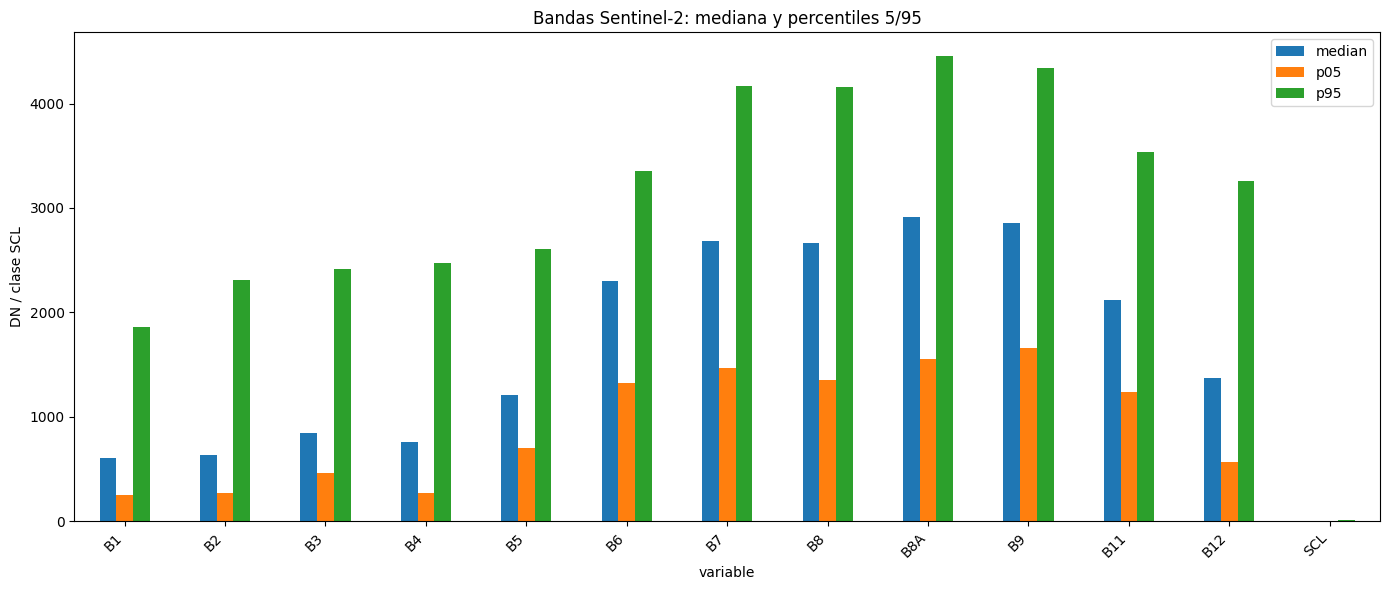

auditoria_tiles_local_output/auditoria_tiles/figuras/bandas_mediana_p05_p95.png


In [14]:
plt.figure(figsize=(14, 6))
stats_bandas.set_index("variable")[["median", "p05", "p95"]].plot(kind="bar", ax=plt.gca())
plt.title("Bandas Sentinel-2: mediana y percentiles 5/95")
plt.ylabel("DN / clase SCL")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
path = FIG_DIR / "bandas_mediana_p05_p95.png"
plt.savefig(path, dpi=160)
plt.show()
print(path)

/tmp/ipykernel_40288/3882461755.py:5: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(datos, labels=CLASES, showfliers=False)
/tmp/ipykernel_40288/3882461755.py:5: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(datos, labels=CLASES, showfliers=False)
/tmp/ipykernel_40288/3882461755.py:5: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(datos, labels=CLASES, showfliers=False)
/tmp/ipykernel_40288/3882461755.py:5: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(

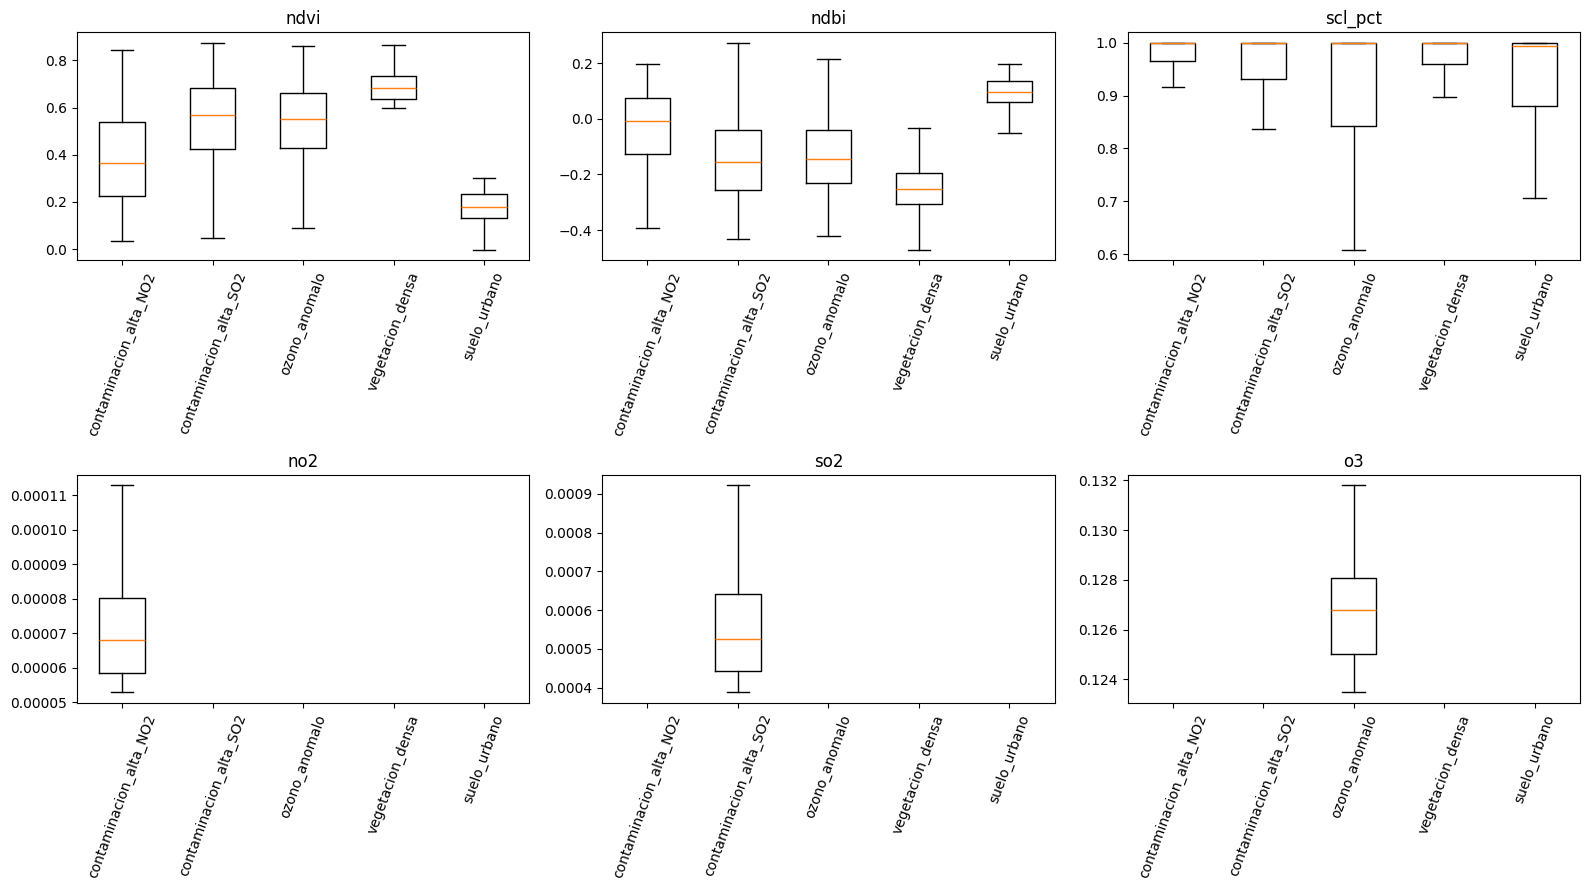

auditoria_tiles_local_output/auditoria_tiles/figuras/variables_clave_por_clase_boxplot.png


In [15]:
fig, axes = plt.subplots(2, 3, figsize=(16, 9))
cols_plot = ["ndvi", "ndbi", "scl_pct", "no2", "so2", "o3"]
for ax, col in zip(axes.ravel(), cols_plot):
    datos = [meta.loc[meta["clase"] == clase, col].dropna().to_numpy() for clase in CLASES]
    ax.boxplot(datos, labels=CLASES, showfliers=False)
    ax.set_title(col)
    ax.tick_params(axis="x", rotation=70)
plt.tight_layout()
path = FIG_DIR / "variables_clave_por_clase_boxplot.png"
plt.savefig(path, dpi=160)
plt.show()
print(path)

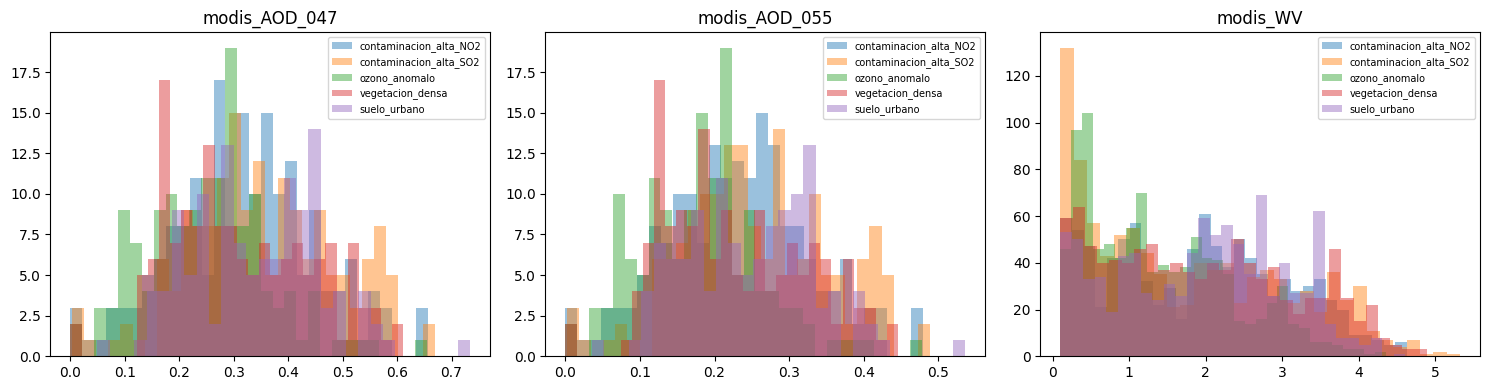

auditoria_tiles_local_output/auditoria_tiles/figuras/modis_distribuciones_por_clase.png


In [16]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, col in zip(axes, ["modis_AOD_047", "modis_AOD_055", "modis_WV"]):
    for clase in CLASES:
        vals = meta.loc[meta["clase"] == clase, col].dropna().to_numpy()
        ax.hist(vals, bins=30, alpha=0.45, label=clase)
    ax.set_title(col)
    ax.legend(fontsize=7)
plt.tight_layout()
path = FIG_DIR / "modis_distribuciones_por_clase.png"
plt.savefig(path, dpi=160)
plt.show()
print(path)

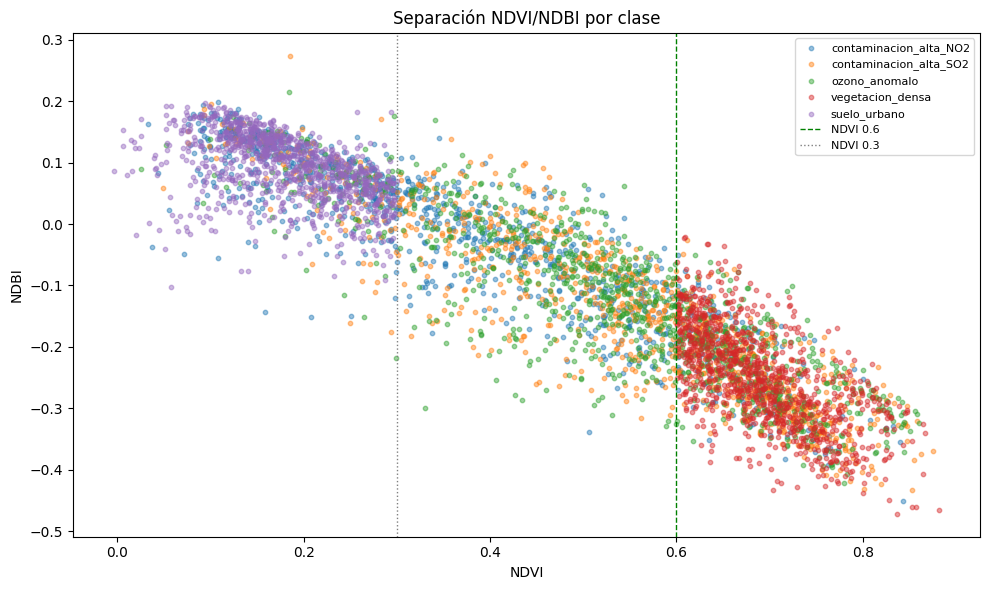

auditoria_tiles_local_output/auditoria_tiles/figuras/ndvi_ndbi_por_clase.png


In [17]:
plt.figure(figsize=(10, 6))
for clase in CLASES:
    g = meta[meta["clase"] == clase]
    plt.scatter(g["ndvi"], g["ndbi"], s=10, alpha=0.45, label=clase)
plt.axvline(0.6, color="green", linestyle="--", linewidth=1, label="NDVI 0.6")
plt.axvline(0.3, color="gray", linestyle=":", linewidth=1, label="NDVI 0.3")
plt.xlabel("NDVI")
plt.ylabel("NDBI")
plt.title("Separación NDVI/NDBI por clase")
plt.legend(fontsize=8)
plt.tight_layout()
path = FIG_DIR / "ndvi_ndbi_por_clase.png"
plt.savefig(path, dpi=160)
plt.show()
print(path)

In [18]:
resumen_final = {
    "tiles_shape": list(tiles.shape),
    "meta_shape": list(meta.shape),
    "bandas": bandas,
    "clases": meta["clase"].value_counts().reindex(CLASES).astype(int).to_dict(),
    "fechas_unicas": int(meta["time_s2"].nunique()),
    "tablas": sorted(p.name for p in TABLE_DIR.glob("*.csv")),
    "figuras": sorted(p.name for p in FIG_DIR.glob("*.png")),
    "rangos_con_alertas": checks_rangos.loc[checks_rangos["n_fuera_rango"] > 0, ["variable", "n_fuera_rango", "pct_fuera_rango", "min_obs", "max_obs"]].to_dict(orient="records"),
}

with open(AUDIT_DIR / "resumen_auditoria_tiles.json", "w") as f:
    json.dump(resumen_final, f, indent=2, ensure_ascii=False)

print(json.dumps(resumen_final, indent=2, ensure_ascii=False))
print(f"Resumen: {AUDIT_DIR / 'resumen_auditoria_tiles.json'}")

{
  "tiles_shape": [
    5000,
    13,
    64,
    64
  ],
  "meta_shape": [
    5000,
    22
  ],
  "bandas": [
    "B1",
    "B2",
    "B3",
    "B4",
    "B5",
    "B6",
    "B7",
    "B8",
    "B8A",
    "B9",
    "B11",
    "B12",
    "SCL"
  ],
  "clases": {
    "contaminacion_alta_NO2": 1000,
    "contaminacion_alta_SO2": 1000,
    "ozono_anomalo": 1000,
    "vegetacion_densa": 1000,
    "suelo_urbano": 1000
  },
  "fechas_unicas": 79,
  "tablas": [
    "checks_rangos_fisicos.csv",
    "conteo_por_anio_clase.csv",
    "conteo_por_fecha_clase.csv",
    "conteo_por_mgrs_clase.csv",
    "distribucion_scl_pixeles.csv",
    "stats_bandas_global.csv",
    "stats_bandas_por_clase.csv",
    "stats_meta_global.csv",
    "stats_meta_por_clase.csv"
  ],
  "figuras": [
    "bandas_mediana_p05_p95.png",
    "modis_distribuciones_por_clase.png",
    "ndvi_ndbi_por_clase.png",
    "variables_clave_por_clase_boxplot.png"
  ],
  "rangos_con_alertas": [
    {
      "variable": "so2",
      "n_fue